In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# 1. Definir lista de acciones y benchmark
stockList = ['MSFT', 'AAPL', 'NVDA', 'AMZN', 'META', 'GOOGL']
market_ticker = '^GSPC'  # S&P 500

In [3]:
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=5 * 365) 

In [ ]:
# 2. Descargar todos los precios de cierre ajustados juntos
tickers = stockList + [market_ticker]
stock_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,  # Ajusta automáticamente dividendos/splits en 'Close'
    multi_level_index=False,  # Mantiene un índice de columnas plano
)['Close']

[*********************100%***********************]  7 of 7 completed


In [6]:
stock_data.tail(10)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,^GSPC
Date,,,,,,,
2026-08-24,310.339996,262.070007,347.836426,559.020020,487.309998,208.479996,7652.859863
2026-08-25,309.899994,261.059998,346.737122,570.049988,491.709991,213.050003,7677.279785
2026-08-26,313.450012,260.279999,341.780304,576.140015,496.369995,209.660004,7675.700195
2026-08-27,314.579987,256.260010,340.431183,571.099976,505.059998,227.979996,7730.990234
2026-08-28,319.700012,266.429993,346.367371,578.020020,513.530029,217.550003,7711.759766
2026-08-31,316.850006,259.769989,339.132019,572.340027,507.290009,220.779999,7686.140137
2026-09-01,325.130005,254.919998,334.804779,578.539978,501.019989,217.440002,7631.470215
2026-09-02,324.959991,254.979996,336.903442,592.849976,496.820007,224.410004,7666.600098
2026-09-03,328.209991,258.899994,342.260010,610.679993,510.119995,228.449997,7747.709961


$$\mathrm{Return}(t)=\frac{\mathrm{Price}(t)-\mathrm{Price}(t-1)}{\mathrm{Price}(t-1)}$$

In [9]:
# 3. Calcular retornos diarios y eliminar NaNs
returns = stock_data.pct_change().dropna()
returns.tail(10)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,^GSPC
Date,,,,,,,
2026-08-24,0.003200,0.013301,0.009396,0.016585,0.008422,-0.029061,-0.002803
2026-08-25,-0.001418,-0.003854,-0.003160,0.019731,0.009029,0.021921,0.003191
2026-08-26,0.011455,-0.002988,-0.014296,0.010683,0.009477,-0.015912,-0.000206
2026-08-27,0.003605,-0.015445,-0.003947,-0.008748,0.017507,0.087380,0.007203
2026-08-28,0.016276,0.039686,0.017437,0.012117,0.016770,-0.045750,-0.002487
2026-08-31,-0.008915,-0.024997,-0.020889,-0.009827,-0.012151,0.014847,-0.003322
2026-09-01,0.026132,-0.018670,-0.012760,0.010833,-0.012360,-0.015128,-0.007113
2026-09-02,-0.000523,0.000235,0.006268,0.024735,-0.008383,0.032055,0.004603
2026-09-03,0.010001,0.015374,0.015899,0.030075,0.026770,0.018003,0.010580


In [10]:
returns.shape

(1254, 7)

In [11]:
# 4. Calcular betas usando la matriz de covarianza
cov_matrix = returns.cov()
market_variance = returns[market_ticker].var()

In [20]:
betas = cov_matrix[market_ticker] / market_variance
betas = betas.drop(market_ticker)
betas_series = pd.Series(betas, name='Beta')
print(betas_series)

Ticker
AAPL     1.187320
AMZN     1.507991
GOOGL    1.265414
META     1.609636
MSFT     1.148730
NVDA     2.170393
Name: Beta, dtype: float64


La cantidad de registros corresponde a la cantidad de días quitando fines de semana y feriados.

In [66]:
mean_returns = returns.mean()
mean_returns

Ticker
AAPL     0.005502
AMZN    -0.004297
GOOGL   -0.010212
META    -0.002172
MSFT    -0.001294
NVDA     0.004090
dtype: float64

Para cualquier par de activos (por ejemplo, $X$ para AAPL y $Y$ para AMZN), Pandas aplica la fórmula de la covarianza muestral:
$$\text{cov}(X, Y) = \frac{1}{N - 1} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})$$
Donde: $N$ es el número total de días u observaciones . Se divide entre $N-1$ porque estamos trabajando con una muestra de datos, no con la población completa. $x_i$ e $y_i$ son los rendimientos de cada día para cada acción. $\bar{x}$ y $\bar{y}$ son las medias de los rendimientos de todo el período para esas acciones.

In [67]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Ticker,,,,,,
AAPL,0.000310,0.000117,0.000136,0.000064,0.000120,-0.000103
AMZN,0.000117,0.000338,0.000428,0.000321,0.000211,0.000035
GOOGL,0.000136,0.000428,0.000725,0.000421,0.000208,0.000274
META,0.000064,0.000321,0.000421,0.000915,0.000198,0.000312
MSFT,0.000120,0.000211,0.000208,0.000198,0.000283,-0.000137
NVDA,-0.000103,0.000035,0.000274,0.000312,-0.000137,0.000667


In [68]:
corr_matrix = returns.corr()
corr_matrix.round(2) * 100

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Ticker,,,,,,
AAPL,100.0,36.0,29.0,12.0,41.0,-23.0
AMZN,36.0,100.0,87.0,58.0,68.0,7.0
GOOGL,29.0,87.0,100.0,52.0,46.0,39.0
META,12.0,58.0,52.0,100.0,39.0,40.0
MSFT,41.0,68.0,46.0,39.0,100.0,-32.0
NVDA,-23.0,7.0,39.0,40.0,-32.0,100.0


In [69]:
# trasforma cov_matrix in a numpy array
cov_matrix_np = cov_matrix.to_numpy()

# calcula determinante de la matriz de covarianza en notacion científica
det_cov_matrix = np.linalg.det(cov_matrix_np)
print(f"Determinante de la matriz de covarianza: {det_cov_matrix:.2e}")

# invierte la matriz de covarianza
inv_cov_matrix = np.linalg.inv(cov_matrix_np)
print(f"Matriz de covarianza invertida:\n{inv_cov_matrix.round(4)}")

# calcula los autovalores de la matriz de covarianza en notación científica
eigenvalues, _ = np.linalg.eigh(cov_matrix_np)
print(f"Autovalores: {eigenvalues.round(4)}")
print(f"Número de condición por autovalores: {eigenvalues.max() / eigenvalues.min():.4f}")


Determinante de la matriz de covarianza: 2.42e-22
Matriz de covarianza invertida:
[[  4212.7779    568.0992  -1257.3216   -121.4125   -691.3358   1052.1341]
 [   568.0992  27938.1955 -15386.2134  -3860.1417  -4181.2522   5887.0904]
 [ -1257.3216 -15386.2134  11664.9394   2016.8037   -537.2542  -5235.2495]
 [  -121.4125  -3860.1417   2016.8037   2546.4694  -1367.5989  -2116.867 ]
 [  -691.3358  -4181.2522   -537.2542  -1367.5989   9745.7771   2982.0783]
 [  1052.1341   5887.0904  -5235.2495  -2116.867    2982.0783   5108.8025]]
Autovalores: [0.     0.0001 0.0002 0.0004 0.0008 0.0017]
Número de condición por autovalores: 68.3828


In [70]:
num_condicion = np.linalg.cond(cov_matrix_np)
print(f"Número de condición por función: {num_condicion:.4f}")

Número de condición por función: 68.3828


In [71]:
import plotly.express as px

# 1. Datos y retornos
stocks = ["MSFT", "AAPL", "NVDA", "AMZN", "META", "GOOGL"]
returns = (
    yf.download(stocks, start=dt.datetime.now() - dt.timedelta(days=300))[
        "Close"
    ]
    .pct_change()
    .dropna()
)

dias, kappa = [], []

# 2. Bucle de número de condición
for d in range(150, 2, -1):
    cov = returns.tail(d).cov().to_numpy()
    ev = np.linalg.eigh(cov)[0]
    k = ev[-1] / ev[0] if ev[0] > 1e-12 else float("inf")
    dias.append(d)
    kappa.append(k)
    if k > 10000:
        print(f"Se alcanzó el umbral en {d} días y kappa={k:.2f}")
        break

# 3. Gráfico minimalista con Plotly Express
fig = px.line(x=dias, y=kappa, log_y=True, markers=True)
fig.add_hline(y=10000, line_dash="dash", line_color="black")
fig.update_layout(
    width=1200,
    height=350,
    xaxis=dict(title="Días hacia atrás", autorange="reversed"),
    yaxis_title="Kappa",
    margin=dict(l=10, r=10, t=10, b=10),
)
fig.show()

[*********************100%***********************]  6 of 6 completed


Se alcanzó el umbral en 6 días y kappa=inf


In [2]:
import numpy as np
import pandas as pd

# 1. Matriz de Correlaciones (R) - 13x13 clases de activos
# (Se convierten los porcentajes a decimales: e.g., 85% -> 0.85)
R = np.array([
    [1.00, 0.85, 0.75, 0.80, 0.60, 0.60, 0.30, 0.10, 0.40, 0.00, 0.00, 0.15, 0.10], # Domestic Equity
    [0.85, 1.00, 0.80, 0.65, 0.60, 0.60, 0.35, 0.15, 0.40, 0.00, 0.20, 0.10, 0.10], # Foreign Equity
    [0.75, 0.80, 1.00, 0.60, 0.60, 0.60, 0.40, 0.20, 0.40, -0.10, 0.00, 0.00, 0.00], # Emerging Markets
    [0.80, 0.65, 0.60, 1.00, 0.60, 0.60, 0.15, 0.10, 0.20, 0.00, 0.10, 0.10, 0.10], # Private Equity
    [0.60, 0.60, 0.60, 0.60, 1.00, 0.65, 0.10, 0.10, 0.20, 0.20, 0.20, 0.20, 0.10], # Absolute Return
    [0.60, 0.60, 0.60, 0.60, 0.65, 1.00, 0.20, 0.10, 0.20, 0.10, 0.20, 0.20, 0.10], # High Yield
    [0.30, 0.35, 0.40, 0.15, 0.10, 0.20, 1.00, 0.10, 0.00, 0.10, 0.10, 0.40, 0.00], # Commodities
    [0.10, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10, 1.00, 0.10, 0.00, 0.10, 0.00, 0.00], # Natural Resources
    [0.40, 0.40, 0.40, 0.20, 0.20, 0.20, 0.00, 0.10, 1.00, 0.00, 0.20, 0.20, 0.00], # Real Estate
    [0.00, 0.00, -0.10, 0.00, 0.20, 0.10, 0.10, 0.00, 0.00, 1.00, 0.70, 0.60, 0.30], # Domestic Bonds
    [0.00, 0.20, 0.00, 0.10, 0.20, 0.20, 0.10, 0.10, 0.20, 0.70, 1.00, 0.50, 0.30], # Foreign Bonds
    [0.15, 0.10, 0.00, 0.10, 0.20, 0.20, 0.40, 0.00, 0.20, 0.60, 0.50, 1.00, 0.40], # Inflation Indexed
    [0.10, 0.10, 0.00, 0.10, 0.10, 0.10, 0.00, 0.00, 0.00, 0.30, 0.30, 0.40, 1.00]  # Cash
])

# 2. Vector de Desviaciones Estándar (sigma)
std_devs = np.array([
    0.155,  # Domestic Equity (15.5%)
    0.160,  # Foreign Equity (16.0%)
    0.180,  # Emerging Markets (18.0%)
    0.200,  # Private Equity (20.0%)
    0.110,  # Absolute Return (11.0%)
    0.140,  # High Yield (14.0%)
    0.210,  # Commodities (21.0%)
    0.100,  # Natural Resources (10.0%)
    0.150,  # Real Estate (15.0%)
    0.055,  # Domestic Bonds (5.5%)
    0.058,  # Foreign Bonds (5.8%)
    0.051,  # Inflation Indexed (5.1%)
    0.035   # Cash (3.5%)
])

# 3. Crear la matriz diagonal D a partir del vector de desviaciones
D = np.diag(std_devs)

# 4. Calcular la Matriz de Covarianza (Sigma = D * R * D)
# El operador '@' se usa para la multiplicación de matrices en NumPy
harvard_covariance_matrix = D @ R @ D

# Imprimir la matriz resultante
pd.DataFrame(harvard_covariance_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.024025,0.021080,0.020925,0.02480,0.010230,0.013020,0.009765,0.00155,0.00930,0.000000,0.000000,0.001186,0.000543
1,0.021080,0.025600,0.023040,0.02080,0.010560,0.013440,0.011760,0.00240,0.00960,0.000000,0.001856,0.000816,0.000560
2,0.020925,0.023040,0.032400,0.02160,0.011880,0.015120,0.015120,0.00360,0.01080,-0.000990,0.000000,0.000000,0.000000
3,0.024800,0.020800,0.021600,0.04000,0.013200,0.016800,0.006300,0.00200,0.00600,0.000000,0.001160,0.001020,0.000700
4,0.010230,0.010560,0.011880,0.01320,0.012100,0.010010,0.002310,0.00110,0.00330,0.001210,0.001276,0.001122,0.000385
5,0.013020,0.013440,0.015120,0.01680,0.010010,0.019600,0.005880,0.00140,0.00420,0.000770,0.001624,0.001428,0.000490
6,0.009765,0.011760,0.015120,0.00630,0.002310,0.005880,0.044100,0.00210,0.00000,0.001155,0.001218,0.004284,0.000000
7,0.001550,0.002400,0.003600,0.00200,0.001100,0.001400,0.002100,0.01000,0.00150,0.000000,0.000580,0.000000,0.000000
8,0.009300,0.009600,0.010800,0.00600,0.003300,0.004200,0.000000,0.00150,0.02250,0.000000,0.001740,0.001530,0.000000
9,0.000000,0.000000,-0.000990,0.00000,0.001210,0.000770,0.001155,0.00000,0.00000,0.003025,0.002233,0.001683,0.000578


In [3]:
condition_number = np.linalg.cond(harvard_covariance_matrix)
print(f"Número de condición: {condition_number:.4f}")

# calcular determinante de la matriz de covarianza de Harvard
det_harvard_cov_matrix = np.linalg.det(harvard_covariance_matrix)
print(f"Determinante de la matriz de covarianza de Harvard: {det_harvard_cov_matrix:.2e}")

# calcular los autovalores de la matriz de covarianza de Harvard
eigenvalues_harvard, _ = np.linalg.eigh(harvard_covariance_matrix)
print(f"Autovalores de la matriz de covarianza de Harvard: {eigenvalues_harvard.round(4)}")

# calcular la matriz de covarianza invertida de Harvard
inv_harvard_cov_matrix = np.linalg.inv(harvard_covariance_matrix)
print(f"\nMatriz de covarianza invertida:")
df_matriz = pd.DataFrame(inv_harvard_cov_matrix)
df_matriz.round(2)

Número de condición: 297.8975
Determinante de la matriz de covarianza de Harvard: 1.61e-29
Autovalores de la matriz de covarianza de Harvard: [0.0004 0.0006 0.0012 0.0026 0.0037 0.0054 0.0068 0.0097 0.0112 0.0123
 0.0225 0.0411 0.1231]

Matriz de covarianza invertida:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,445.32,-257.03,18.43,-148.50,14.66,-15.73,-13.90,3.39,-75.64,-295.81,468.94,-54.57,-55.04
1,-257.03,300.01,-71.17,60.14,-36.22,-0.05,-9.96,4.92,23.12,215.04,-359.86,89.08,-20.67
2,18.43,-71.17,149.97,-16.72,-52.80,-29.48,-42.53,-16.24,-48.54,-55.42,102.82,149.03,-49.54
3,-148.50,60.14,-16.72,103.64,-22.21,-9.61,12.47,-1.09,33.87,117.44,-154.17,-10.48,17.27
4,14.66,-36.22,-52.80,-22.21,212.81,-41.90,33.54,0.03,21.76,-81.99,34.36,-105.17,55.50
5,-15.73,-0.05,-29.48,-9.61,-41.90,114.48,7.95,2.66,16.16,44.83,-54.92,-59.95,20.97
6,-13.90,-9.96,-42.53,12.47,33.54,7.95,52.93,-2.19,32.93,38.10,-22.48,-152.41,71.91
7,3.39,4.92,-16.24,-1.09,0.03,2.66,-2.19,106.64,-0.99,15.15,-35.33,10.29,0.23
8,-75.64,23.12,-48.54,33.87,21.76,16.16,32.93,-0.99,93.51,117.35,-133.40,-135.69,80.35
9,-295.81,215.04,-55.42,117.44,-81.99,44.83,38.10,15.15,117.35,1118.75,-815.61,-379.80,72.86


--- ESTADÍSTICAS DEL NÚMERO DE CONDICIÓN ---
Valor Base Original : 297.8975
Mínimo Encontrado   : 94.3597
Máximo Encontrado   : 4647.1610
Media (Promedio)    : 946.2027
Mediana             : 787.5348
Desviación Estándar : 591.6412


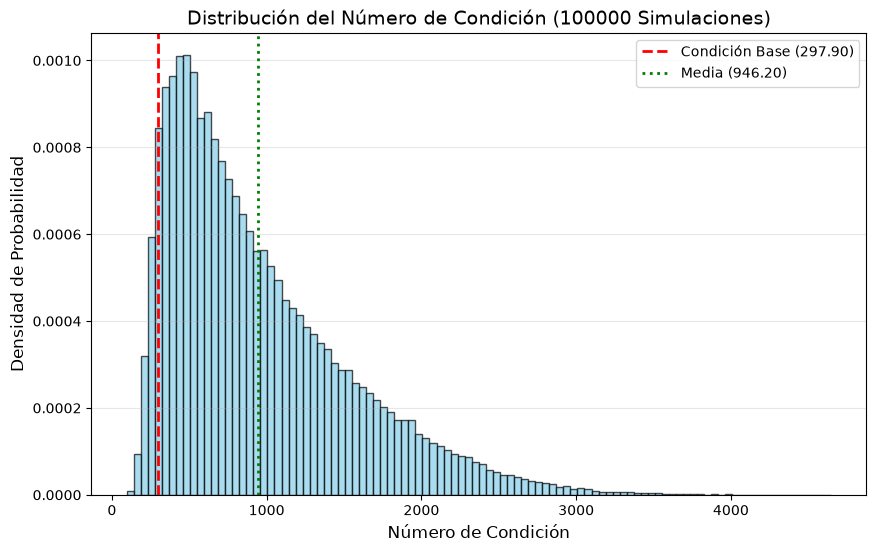

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Definición de Datos Iniciales ---
R = np.array([
    [1.00, 0.85, 0.75, 0.80, 0.60, 0.60, 0.30, 0.10, 0.40, 0.00, 0.00, 0.15, 0.10],
    [0.85, 1.00, 0.80, 0.65, 0.60, 0.60, 0.35, 0.15, 0.40, 0.00, 0.20, 0.10, 0.10],
    [0.75, 0.80, 1.00, 0.60, 0.60, 0.60, 0.40, 0.20, 0.40, -0.10, 0.00, 0.00, 0.00],
    [0.80, 0.65, 0.60, 1.00, 0.60, 0.60, 0.15, 0.10, 0.20, 0.00, 0.10, 0.10, 0.10],
    [0.60, 0.60, 0.60, 0.60, 1.00, 0.65, 0.10, 0.10, 0.20, 0.20, 0.20, 0.20, 0.10],
    [0.60, 0.60, 0.60, 0.60, 0.65, 1.00, 0.20, 0.10, 0.20, 0.10, 0.20, 0.20, 0.10],
    [0.30, 0.35, 0.40, 0.15, 0.10, 0.20, 1.00, 0.10, 0.00, 0.10, 0.10, 0.40, 0.00],
    [0.10, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10, 1.00, 0.10, 0.00, 0.10, 0.00, 0.00],
    [0.40, 0.40, 0.40, 0.20, 0.20, 0.20, 0.00, 0.10, 1.00, 0.00, 0.20, 0.20, 0.00],
    [0.00, 0.00, -0.10, 0.00, 0.20, 0.10, 0.10, 0.00, 0.00, 1.00, 0.70, 0.60, 0.30],
    [0.00, 0.20, 0.00, 0.10, 0.20, 0.20, 0.10, 0.10, 0.20, 0.70, 1.00, 0.50, 0.30],
    [0.15, 0.10, 0.00, 0.10, 0.20, 0.20, 0.40, 0.00, 0.20, 0.60, 0.50, 1.00, 0.40],
    [0.10, 0.10, 0.00, 0.10, 0.10, 0.10, 0.00, 0.00, 0.00, 0.30, 0.30, 0.40, 1.00]
])

std_devs = np.array([0.155, 0.160, 0.180, 0.200, 0.110, 0.140, 0.210, 0.100, 0.150, 0.055, 0.058, 0.051, 0.035])

# --- 2. Parámetros de la Simulación ---
n_iterations = 100000  # Número de repeticiones (puedes cambiarlo a 1000, 10000 o 100000)
epsilon = 0.7          # Variación máxima del 5% (en términos relativos)

# Fijar semilla para reproducibilidad
np.random.seed(42)

# --- 3. Generación de Perturbaciones Aleatorias (Distribución Uniforme) ---
# Creamos un factor multiplicativo aleatorio entre (1 - epsilon) y (1 + epsilon) para cada iteración y cada activo
# El tamaño de la matriz de factores será (n_iterations, 13)
random_factors = np.random.uniform(1 - epsilon, 1 + epsilon, size=(n_iterations, len(std_devs)))
perturbed_std_devs = std_devs * random_factors

# --- 4. Cálculo Vectorizado de los Números de Condición ---
condition_numbers = []

for i in range(n_iterations):
    # Obtener el vector perturbado para esta iteración
    s = perturbed_std_devs[i]
    
    # Construir Sigma de forma eficiente: multiplicar filas y columnas usando 'broadcasting'
    # s[:, None] multiplica las filas, s[None, :] multiplica las columnas
    sigma_perturbed = R * s[:, None] * s[None, :]
    
    # Calcular número de condición y guardar
    cond = np.linalg.cond(sigma_perturbed)
    condition_numbers.append(cond)

condition_numbers = np.array(condition_numbers)

# --- 5. Análisis de Resultados Estadísticos ---
cond_base = np.linalg.cond(np.diag(std_devs) @ R @ np.diag(std_devs))

print("--- ESTADÍSTICAS DEL NÚMERO DE CONDICIÓN ---")
print(f"Valor Base Original : {cond_base:.4f}")
print(f"Mínimo Encontrado   : {np.min(condition_numbers):.4f}")
print(f"Máximo Encontrado   : {np.max(condition_numbers):.4f}")
print(f"Media (Promedio)    : {np.mean(condition_numbers):.4f}")
print(f"Mediana             : {np.median(condition_numbers):.4f}")
print(f"Desviación Estándar : {np.std(condition_numbers):.4f}")

# --- 6. Graficar la Distribución ---
plt.figure(figsize=(10, 6))
plt.hist(condition_numbers, bins=100, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(cond_base, color='red', linestyle='dashed', linewidth=2, label=f'Condición Base ({cond_base:.2f})')
plt.axvline(np.mean(condition_numbers), color='green', linestyle=':', linewidth=2, label=f'Media ({np.mean(condition_numbers):.2f})')

plt.title(f'Distribución del Número de Condición ({n_iterations} Simulaciones)', fontsize=14)
plt.xlabel('Número de Condición', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()